# <u> **Comment Letters Stakeholder Engagement or Orientation NLP Analysis** </u>

### **ANalysis Steps:**
- Collect comment letters from EDGAR or SEC correspondence databases.
- Preprocess letters to focus on stakeholder-related comments.
- Apply LDA to extract engagement themes (e.g., customer disclosure deficiencies).
- Use sentiment analysis to evaluate company response tone.
- Track issue resolution using sequence modeling or text similarity.

### **Challenges:**
- Technical regulatory language requires specialized NLP models.
- Limited public access to comment letters restricts analysis.
- Contextual understanding of stakeholder regulations is complex.

### **Example:**
- An SEC comment might state: “Provide additional disclosure on stakeholder engagement practices.” NLP can extract “stakeholder engagement” as a focus area and analyze the company’s response tone for compliance signals.

### **Information on Data Used:**
- For This analysis, two comment letters will be used: 
- NVIDIA's June 29, 2023 comment letter https://www.sec.gov/Archives/edgar/data/1045810/000104581023000160/filename1.htm, and
- NVIDIA's July 31, 2025 comment letter https://www.sec.gov/Archives/edgar/data/1045810/000104581025000192/filename1.htm.

---

## **Importing Packages:**

In [1]:
from MyPackages import *


---

## **Collect comment letters from EDGAR or SEC correspondence databases:**

> The first html web page that will be extracted is the 2023 NVIDIA comment letter.

In [2]:
soup = web_text('https://www.sec.gov/Archives/edgar/data/1045810/000104581023000160/filename1.htm')

lst = []

for i in soup.find_all('font'):
    lst.append(i.get_text(strip= True))

for i in range(len(lst)):
    print(i, ' - ', lst[i])

0  -  
1  -  
2  -  VIA EDGAR
3  -  
4  -  June 29, 2023
5  -  
6  -  United States Securities and Exchange Commission
7  -  100 F Street, N.E.
8  -  Washington, D.C. 20549
9  -  Attn: Charles Eastman or Claire Erlanger
10  -  
11  -  RE:    NVIDIA Corporation
12  -  Form 10-K for the Year Ended January 29, 2023
13  -  Filed February 24, 2023
14  -  File No. 000-23985
15  -  
16  -  Dear Mr. Eastman and Ms. Erlanger,
17  -  
18  -  On behalf of NVIDIA Corporation (“NVIDIA”, “we”, or the “Company”), I am responding to the comments received from the staff (the “Staff”) of the Securities and Exchange Commission by letter dated June 15, 2023, with respect to NVIDIA’s Form 10-K listed above (the “Comments”). The numbering of the paragraphs below corresponds to the numbering of the Comments, which for the Staff’s convenience have been incorporated into this response letter. The Company respectfully acknowledges the Staff’s Comments.
19  -  Management's Discussion and Analysis of Financial Co

In [3]:
df_2023 = {'year': 2023, 'text': lst}
df_2023 = pd.DataFrame(df_2023)
df_2023

,year,text
0,2023,
1,2023,
2,2023,VIA EDGAR
3,2023,
4,2023,"June 29, 2023"
...,...,...
69,2023,Eric C. Jensen – Cooley LLP
70,2023,Scott Almassy – PricewaterhouseCoopers LLP
71,2023,
72,2023,


> The second page downloaded is the 2025 comment letter.

In [4]:
soup = web_text('https://www.sec.gov/Archives/edgar/data/1045810/000104581025000192/filename1.htm')

lst = []

for i in soup.find_all('font'):
    lst.append(i.get_text(strip= True))

for i in range(len(lst)):
    print(i, ' - ', lst[i])

0  -  
1  -  
2  -  
3  -  VIA EDGAR
4  -  
5  -  July 31, 2025
6  -  
7  -  United States Securities and Exchange Commission
8  -  100 F Street, N.E.
9  -  Washington, D.C. 20549
10  -  Attn: Claire Erlanger or Kevin Woody
11  -  
12  -  RE:    NVIDIA Corporation
13  -  Form 10-K for the Fiscal Year Ended January 26, 2025
14  -  Form 8-K furnished May 28, 2025
15  -  File No. 000-23985
16  -  
17  -  Dear Ms. Erlanger and Mr. Woody,
18  -  
19  -  On behalf of NVIDIA Corporation (“NVIDIA”, “we”, or the “Company”), I am responding to the comments received from the staff (the “Staff”) of the Securities and Exchange Commission by letter dated July 22, 2025, with respect to NVIDIA’s Form 10-K for the fiscal year ended January 26, 2025 (the “Form 10-K”) and Form 8-K listed above (the “Comments”). The numbering of the paragraphs below corresponds to the numbering of the Comments, which for the Staff’s convenience have been incorporated into this response letter. The Company respectfully ack

In [5]:
df_2025 = {'year': 2025, 'text': lst}
df_2025 = pd.DataFrame(df_2025)
df_2025

,year,text
0,2025,
1,2025,
2,2025,
3,2025,VIA EDGAR
4,2025,
...,...,...
80,2025,John McKenna – Cooley LLP
81,2025,
82,2025,
83,2025,


In [6]:
df = pd.concat([df_2023, df_2025])

df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)

df

,year,text
0,2023,
1,2023,
2,2023,VIA EDGAR
3,2023,
4,2023,"June 29, 2023"
...,...,...
154,2025,John McKenna – Cooley LLP
155,2025,
156,2025,
157,2025,


> Both 2023 and 2025 comment letter dataframes have been concatenated, which means combined on the same columns (year and text). The index has also been reset. This is the dataset which will be used during the analyses.

## **Preprocess letters to focus on stakeholder-related comments:**

In [7]:
df = df[df['text'].str.len() >= 1]

> Each row of text which contain a blank space have been removed.

In [8]:
newList = []
newYears = []

current = ""
current_year = None

for text, year in zip(df['text'], df['year']):
    current += " " + text

    if current_year is None:
        current_year = year

    if text.endswith("."):
        newList.append(current.strip())
        newYears.append(current_year)

        current = ""
        current_year = None

df = pd.DataFrame({
    'year': newYears,
    'text': newList
})

> When the lines of text are parsed into python using the BeautifulSoup package, many sentences are split where one half of the sentence appears on a line below the rest of the sentence. This code combines all sentences back together based on periods. It searches the list for any line of text without a period on the end. Once it finds a line of text with a period, it then combines all those lines together. Full sentences starting with a capital letter and ending with a period are produced. 

In [9]:
df = df[df['text'].str.len() >= 100]
df['text'] = df['text'].str.replace(r'\d+\s+\d+\.', '', regex=True)
df['text'] = df['text'].str.replace('page', '')
df['text'] = df['text'].str.replace('* * * * ', '')
df['text'] = df['text'].str.replace('  ', '')

In [10]:
df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)

> This is the final complete text column for the dataframe. Random sentences with no reason to be in the dataframe, and those that will not add any value to the analysis have been removed. Symbols, page numbers, and random spaces within the text have also been removed.

## **Apply LDA to extract engagement themes (e.g., customer disclosure deficiencies):**

In [11]:
vector = count_vector(stop_words= 'english')
transformed = vector.fit_transform(df['text'])

> In order to use the Latent Dirichlet Allocation model, the data must first be transformed into numerical values.

In [12]:
ldaModel = lda(n_components= 3, random_state= 42).fit(transformed)

> The Latent Dirichlet Allocation model extracts the main topics from the transformed lines of text.

In [13]:
words = vector.get_feature_names_out()
weights = ldaModel.components_

> The words have been extracted from the count vectorizer model, and the weights of the words for each topic have been extracted from the Latent Dirichlet Allocation model.

In [14]:
topics = {
    'words': words,
    'topic0': weights[0],
    'topic1': weights[1],
    'topic2': weights[2]
}

topics = pd.DataFrame(topics)

> These words and weights for each word have all been combined under one single dataframe.

In [15]:
topics[['words', 'topic0']].sort_values(by= 'topic0', ascending= False).head(10)

,words,topic0
411,segment,9.337832
217,h20,8.337999
151,discussion,8.331836
74,change,7.333203
345,products,7.164840
255,item,6.337523
316,operations,6.332926
234,income,6.332244
280,market,6.329763
396,results,5.358324


> The first topic of the two NVIDIA comment letters from 2023 and 2025 includes discussions on change, products/items, operations, income, markets, and results. The first topic could be classified as discussions on change of products/items and operations. This topic does include stakeholder engagement themes.

In [16]:
topics[['words', 'topic1']].sort_values(by= 'topic1', ascending= False).head(10)

,words,topic1
397,revenue,16.323827
432,staff,12.250617
94,company,10.333214
11,2025,10.254422
3,10,10.168101
302,nvidia,9.353690
202,form,9.256335
91,comments,8.333262
344,product,6.612429
298,note,6.608943


> The next topic of the two NVIDIA comment letters from 2023 and 2025 includes company revenue and staff, which the overall topic of the text can be classified as. This topic can be considered as a stakeholder engagement theme, but it is also more in line with finance and the supply chains.

In [17]:
topics[['words', 'topic2']].sort_values(by= 'topic2', ascending= False).head(10)

,words,topic2
76,charge,9.355792
205,gaap,7.309930
252,inventory,6.355484
296,non,6.302491
217,h20,5.794196
199,financial,5.380194
315,operating,5.363139
298,note,5.335137
234,income,4.343888
304,obligations,4.337464


> The third and final topic of the two NVIDIA comment letters from 2023 and 2025 includes product charges, gaap, inventory, income, and finance and operations. This topic can therefore be classified as finance and operations, which does not include stakeholder engagement themes and is more in line with finances and economics.

## **Use sentiment analysis to evaluate company response tone:**

In [18]:
finbertOutput = finbert(df['text'].tolist())

finbertOutput = pd.DataFrame(finbertOutput)
df = pd.merge(df, finbertOutput, left_index= True, right_index= True)
df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,year,text,label,score
0,2023,"Washington, D.C. 20549 Attn: Charles Eastman o...",neutral,0.947943
1,2023,Management's Discussion and Analysis of Financ...,neutral,0.941472
2,2023,Where you describe two or more business reason...,neutral,0.538620
3,2023,"In response to the Staff’s Comment, in future ...",neutral,0.814429
4,2023,Management's Discussion and Analysis of Financ...,neutral,0.941472
5,2023,We note your risk factor disclosure which iden...,neutral,0.906161
6,2023,"In response to the Staff’s Comment, in future ...",neutral,0.880130
7,2023,Management's Discussion and Analysis of Financ...,neutral,0.945565
8,2023,We note your narrative discussion of the drive...,neutral,0.933203
9,2023,"In response to the Staff’s Comment, in future ...",neutral,0.838394


> The lines of text have been input into the FinBERT model, and the model's sentiment analysis output has been added to the dataframe. The data under the labels column includes the sentiment analysis where each line of text is viewed by FinBERT as positive, negative, or neutral. A confidence score is also given, which tells how accurate FinBERT's classification is.

In [19]:
counts = df['label'].value_counts().reset_index()
counts

,label,count
0,neutral,28
1,positive,2
2,negative,1


In [20]:
df['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,neutral,0.903226
1,positive,0.064516
2,negative,0.032258


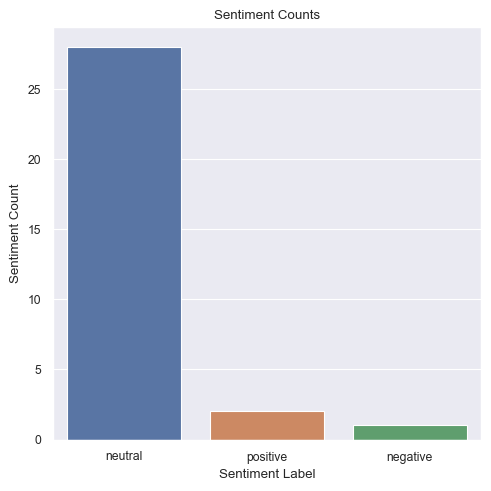

In [21]:
sns.set_theme('paper')
plt.figure(figsize= (5, 5))

sns.barplot(data= counts, x= 'label', y= 'count', hue= 'label')
plt.title('Sentiment Counts')
plt.xlabel('Sentiment Label')
plt.ylabel('Sentiment Count')

plt.tight_layout()
plt.show()

> As shown by the graph and the two tables above, the majority of the lines of text have been labeled as neutral sentiment by FinBERT. 90% with a count of 28 came back as neutral, while only 6.4% with a count of 2 lines of text are viewed as positive by the model. As for negatively viewed lines of text, this consists of only 3% with a count of 1 line.

In [23]:
df[df['label'] == 'positive']['text'].tolist()

['We respectfully advise the Staff that the H20 data center product was designed specifically for the Chinese market in conformance with specific USG license requirements, and there is not a market outside of China for H20. The manufacturing process and components for the H20 products are unique to our previous Hopper architecture and the Chinese market. Current demand from customers, not subject to an export control license, is primarily for our latest Blackwell architecture products, which has a significant improvement in performance and efficiency compared to the Hopper architecture products and H20. Outside of the China market for which the H20 products were specifically designed, there is minimal alternative use given the increased speed of NVIDIA product innovation, product releases and increased performance customers receive with the current Blackwell products.',
 'Investors indicated that the supplemental disclosure provided transparency and helped them understand the impact of

> Both lines of text labeled as positive are from the 2025 NVIDIA comment letter, as seen above. The first line of text is: "We respectfully advise the Staff that the H20 data center product was designed specifically for the Chinese market in conformance with specific USG license requirements, and there is not a market outside of China for H20. The manufacturing process and components for the H20 products are unique to our previous Hopper architecture and the Chinese market. Current demand from customers, not subject to an export control license, is primarily for our latest Blackwell architecture products, which has a significant improvement in performance and efficiency compared to the Hopper architecture products and H20. Outside of the China market for which the H20 products were specifically designed, there is minimal alternative use given the increased speed of NVIDIA product innovation, product releases and increased performance customers receive with the current Blackwell products". This positively viewed line of text discusses the product H20, which is specifically designed and designated for the Chinese market and Chinese consumers only. The second is: "Investors indicated that the supplemental disclosure provided transparency and helped them understand the impact of this unique event on our financial results and enabled investors to compare our operating performance from period-to-period on a more consistent basis". The reason this line of text is positive is because it states that investors found that supplemental disclosures provided transparency, and that it helped them understand the impact of unique events on financial results.

In [25]:
df[df['label'] == 'negative']['text'].tolist()

['NVIDIA incurred a $4.5 billion charge in the first quarter of fiscal 2026 associated with H20 excess inventory and purchase obligations as the demand for H20 diminished. This charge was significant and unprecedented. We respectfully submit that the charge relating to our first quarter of fiscal 2026 H20 charge for excess inventory and purchase obligations was not a normal recurring operating cost of our business.']

> The one and only negative line of text is: "NVIDIA incurred a $4.5 billion charge in the first quarter of fiscal 2026 associated with H20 excess inventory and purchase obligations as the demand for H20 diminished. This charge was significant and unprecedented. We respectfully submit that the charge relating to our first quarter of fiscal 2026 H20 charge for excess inventory and purchase obligations was not a normal recurring operating cost of our business". The reason this line of text is very negative is because it discusses diminishing demand for the H20 product in Chinese markets, and a $4.5 billion charge NVIDIA incurred in the first quarter because of the loss of demand.

## **Track issue resolution using sequence modeling or text similarity:**

In [26]:
vector = tf_idf(stop_words= 'english')
transformed = vector.fit_transform(df['text'])

> First the lines of text must be transformed. Each word is represented by a numerical value based on their importance. This is determined by the TF-IDF model.

In [27]:
cosineModel = cosine_similarity(transformed)

> The Cosine Similarity model is employed to determine how similar each line of text is to another. It produces a matrix and prints a percentage for each element. The percentage can be interpreted as how similar each text is to another.

In [28]:
lst = []

for i in range(len(cosineModel)):
    largest = 0
    index = 0
    for k in range(len(cosineModel)):
        if (i != k) and (cosineModel[i][k] >= largest):
            largest = cosineModel[i][k]
            index = k
    lst.append(index)

df['similar'] = lst
df

,year,text,label,score,similar
0,2023,"Washington, D.C. 20549 Attn: Charles Eastman o...",neutral,0.947943,15
1,2023,Management's Discussion and Analysis of Financ...,neutral,0.941472,4
2,2023,Where you describe two or more business reason...,neutral,0.538620,3
3,2023,"In response to the Staff’s Comment, in future ...",neutral,0.814429,2
4,2023,Management's Discussion and Analysis of Financ...,neutral,0.941472,1
5,2023,We note your risk factor disclosure which iden...,neutral,0.906161,6
6,2023,"In response to the Staff’s Comment, in future ...",neutral,0.880130,5
7,2023,Management's Discussion and Analysis of Financ...,neutral,0.945565,4
8,2023,We note your narrative discussion of the drive...,neutral,0.933203,9
9,2023,"In response to the Staff’s Comment, in future ...",neutral,0.838394,8


> This code takes the Cosine Similarity matrix and converts it into a neat column in the dataframe. The code looks at each line of text and looks for the index of another line of text it is most similar to. For example, the second line of text under index 1 "Management's Discussion and Analysis of Financ..." has been identified to be most similar to the line of text under index 4 "Management's Discussion and Analysis of Financ...". Similarly, index 4 text is most similar to index 1 text. 

In [29]:
counts = df['similar'].value_counts().reset_index().head(6)
counts

,similar,count
0,4,3
1,15,2
2,16,2
3,21,2
4,11,2
5,6,1


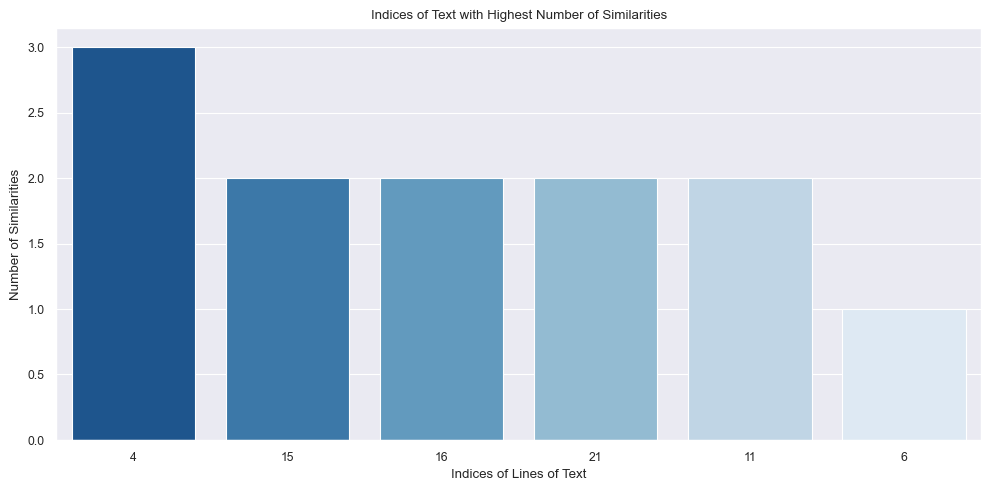

In [30]:
sns.set_theme('paper')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'similar', y= 'count', order= counts['similar'].tolist(), palette= 'Blues_r')
plt.title('Indices of Text with Highest Number of Similarities')
plt.xlabel('Indices of Lines of Text')
plt.ylabel('Number of Similarities')

plt.tight_layout()
plt.show()

> As seen by the chart and the table above, the line of text that is most similar to other lines is under index 4.

In [31]:
df['text'][4]

"Management's Discussion and Analysis of Financial Condition and Results of Operations Results of Operations,"

> The line of text at index 4 is "Management's Discussion and Analysis of Financial Condition and Results of Operations Results of Operations". As you probably can tell, this line of text is obviously a heading of a section from one of the comment letters. This is because each of the words are capitalized, and there is no further explanation as to what the management discussion and analysis really is. Therefore, the lines similar to this one must be lines of text which give more information on this subject.

In [32]:
df[df['similar'] == 4]['text'].tolist()

["Management's Discussion and Analysis of Financial Condition and Results of Operations Results of Operations,",
 "Management's Discussion and Analysis of Financial Condition and Results of Operations Gross Profit and Gross Margin,",
 'Investors indicated that the supplemental disclosure provided transparency and helped them understand the impact of this unique event on our financial results and enabled investors to compare our operating performance from period-to-period on a more consistent basis.']

> As viewed above, the first two lines of text that are similar to index 4 text are also headings of sections. The first is from index 1: "Management's Discussion and Analysis of Financial Condition and Results of Operations Results of Operations", and the second is from index 7: "Management's Discussion and Analysis of Financial Condition and Results of Operations Gross Profit and Gross Margin". The third line of text from index 22 is an actual response given by NVIDIA. It states that "Investors indicated that the supplemental disclosure provided transparency and helped them understand the impact of this unique event on our financial results and enabled investors to compare our operating performance from period-to-period on a more consistent basis". This is the response to the discussion proposed by the heading "Management's Discussion and Analysis of Financial Condition and Results of Operations Results of Operations". This line of text is actually the same line classified as positive sentiment by FinBERT.